In [ ]:
from google.colab import files
uploaded = files.upload()

Saving QSAR_EGFR_preprocessed.csv to QSAR_EGFR_preprocessed (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv('QSAR_EGFR_preprocessed (1).csv')
df.head()
df.shape

(91, 6)

In [ ]:
df.columns

Index(['molecule_chembl_id', 'canonical_smiles', 'standard_type',
       'standard_value', 'standard_units', 'bioactivity_class'],
      dtype='object')

In [ ]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   molecule_chembl_id  91 non-null     object 
 1   canonical_smiles    91 non-null     object 
 2   standard_type       91 non-null     object 
 3   standard_value      91 non-null     float64
 4   standard_units      91 non-null     object 
 5   bioactivity_class   91 non-null     object 
dtypes: float64(1), object(5)
memory usage: 4.4+ KB


,0
molecule_chembl_id,0
canonical_smiles,0
standard_type,0
standard_value,0
standard_units,0
bioactivity_class,0


Rename columns

In [ ]:
df.rename(columns={'standard_value': 'pIC50', 'canonical_smiles': 'SMILES'}, inplace=True)
df.head()

,molecule_chembl_id,SMILES,standard_type,pIC50,standard_units,bioactivity_class
0,CHEMBL292323,COc1cccc2c(C(=O)Nc3ccccc3)c(SSc3c(C(=O)Nc4cccc...,IC50,100.00,µM,inactive
1,CHEMBL304414,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3ccccc3n2C)c(C(=O)N...,IC50,100.00,µM,inactive
2,CHEMBL62176,CN1C(=S)C(C(=O)Nc2ccccc2)c2ccccc21,IC50,100.00,µM,inactive
3,CHEMBL62701,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3cccnc3n2C)c(C(=O)N...,IC50,25.00,µM,inactive
4,CHEMBL137617,C/N=N/Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,IC50,0.07,µM,active


Basic Statistics of pIC50

In [ ]:
df['pIC50'].describe()

,pIC50
count,91.000000
mean,99.208224
std,245.680983
min,0.001600
25%,0.534000
50%,10.000000
75%,46.100000
max,1000.000000


Histogram of pIC50

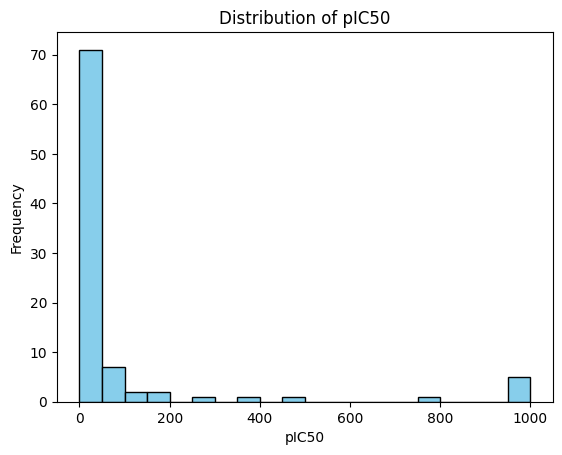

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['pIC50'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('pIC50')
plt.ylabel('Frequency')
plt.title('Distribution of pIC50')
plt.show()

Bioactivity Class Counts

In [ ]:
df['bioactivity_class'].value_counts()

,count
bioactivity_class,
inactive,48
active,27
intermediate,16


Bar Plot of Bioactivity Classes

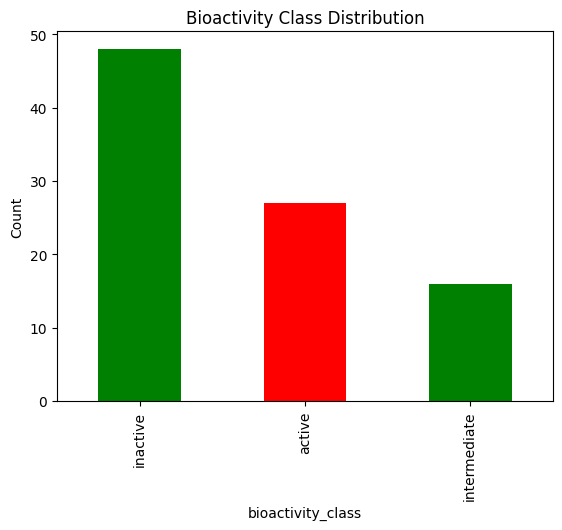

In [ ]:
df['bioactivity_class'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Bioactivity Class Distribution')
plt.ylabel('Count')
plt.show()

Lipinski descriptors & 2D PaDEL descriptors

In [ ]:
!pip install rdkit

In [ ]:
from google.colab import files
uploaded = files.upload()  # This opens a file picker

Saving QSAR_EGFR_preprocessed.csv to QSAR_EGFR_preprocessed (2).csv


In [ ]:
import pandas as pd
import io

df = pd.read_csv(io.BytesIO(uploaded['QSAR_EGFR_preprocessed (2).csv']))

In [ ]:
from rdkit import Chem
import pandas as pd

# Assuming your SMILES column is named 'canonical_smiles'
df['mol'] = df['canonical_smiles'].apply(Chem.MolFromSmiles)

# Check first few rows
df[['canonical_smiles', 'mol']].head()

,canonical_smiles,mol
0,COc1cccc2c(C(=O)Nc3ccccc3)c(SSc3c(C(=O)Nc4cccc...,<rdkit.Chem.rdchem.Mol object at 0x7c1be02c3f40>
1,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3ccccc3n2C)c(C(=O)N...,<rdkit.Chem.rdchem.Mol object at 0x7c1be02c3df0>
2,CN1C(=S)C(C(=O)Nc2ccccc2)c2ccccc21,<rdkit.Chem.rdchem.Mol object at 0x7c1be02c3610>
3,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3cccnc3n2C)c(C(=O)N...,<rdkit.Chem.rdchem.Mol object at 0x7c1be02b9770>
4,C/N=N/Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,<rdkit.Chem.rdchem.Mol object at 0x7c1be021c040>


In [ ]:
from rdkit.Chem import Descriptors

# Example descriptors
df['MolWt'] = df['mol'].apply(Descriptors.MolWt)          # Molecular weight
df['LogP'] = df['mol'].apply(Descriptors.MolLogP)         # Octanol-water partition coefficient
df['HBA'] = df['mol'].apply(Descriptors.NumHAcceptors)    # H-bond acceptors
df['HBD'] = df['mol'].apply(Descriptors.NumHDonors)       # H-bond donors

# Preview the dataframe
df[['canonical_smiles', 'MolWt', 'LogP', 'HBA', 'HBD']].head()

,canonical_smiles,MolWt,LogP,HBA,HBD
0,COc1cccc2c(C(=O)Nc3ccccc3)c(SSc3c(C(=O)Nc4cccc...,622.772,7.9912,6,2
1,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3ccccc3n2C)c(C(=O)N...,562.720,7.9740,4,2
2,CN1C(=S)C(C(=O)Nc2ccccc2)c2ccccc21,282.368,3.1861,2,1
3,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3cccnc3n2C)c(C(=O)N...,564.696,6.7640,6,2
4,C/N=N/Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,357.215,4.5448,5,2


In [ ]:
df_lipinski = df[['molecule_chembl_id','MolWt','LogP','HBA','HBD']]
df_lipinski.to_csv('lipinski_descriptors.csv', index=False)

In [43]:
df[['pIC50','MolWt','LogP','HBA','HBD']].corr()

,pIC50,MolWt,LogP,HBA,HBD
pIC50,1.000000,-0.252588,-0.201006,-0.333334,-0.170038
MolWt,-0.252588,1.000000,0.742968,0.685249,-0.050214
LogP,-0.201006,0.742968,1.000000,0.270523,-0.176618
HBA,-0.333334,0.685249,0.270523,1.000000,0.185739
HBD,-0.170038,-0.050214,-0.176618,0.185739,1.000000


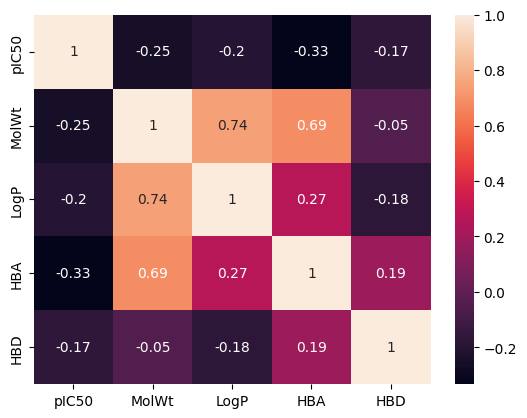

In [44]:
import seaborn as sns

sns.heatmap(df[['pIC50','MolWt','LogP','HBA','HBD']].corr(), annot=True)
plt.show()

In [45]:
from rdkit.Chem import MACCSkeys

df['MACCS'] = df['mol'].apply(MACCSkeys.GenMACCSKeys)

import numpy as np

maccs_df = pd.DataFrame(df['MACCS'].apply(list).to_list())
maccs_df.to_csv('MACCS_fingerprints.csv', index=False)

maccs_df.shape

(91, 167)

In [46]:
df.to_csv('final_dataset_with_descriptors.csv', index=False)